In [1]:
#========================================================================
#
# Name: machine-learning-recursive-feature-elimination.ipynb
#
# Date: 15/04/2026
#
# Author: MT
# 
# Description: Recursive Feature Elimination with Titanic Data
#
# Steps:
# Step 0: Imports
# Step 1: Read Data
# Step 2: Pre-Processing
# Step 3: Encoding  
# Step 4: Train-test split
# Step 5: XGBoost Baseline Model
# Step 6: Recursive Feature Elimination
# Step 7: Results
#
#========================================================================

In [2]:
#========================================================================
# Step 0: Imports

#--------------------
# Pandas Stack
import pandas as pd
import numpy as np
#--------------------

#--------------------
# Helpers
import warnings
warnings.filterwarnings("ignore")
import copy
#--------------------

#--------------------
# WoE Encoding
import category_encoders as ce

# Sampling
from sklearn.model_selection import train_test_split
#--------------------

#--------------------
# XGBoost
from xgboost import XGBClassifier
#--------------------

#--------------------
# Model fit
from sklearn.metrics import roc_auc_score
#--------------------

#--------------------
# SHAP Explainability
import shap
shap.initjs()
#--------------------

#--------------------
# Graphing
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import plotly.express as px
#--------------------

#--------------------
# Data
name='train.csv'
#--------------------
#========================================================================

In [ ]:
#================================================================================
# Step 1: Read Data
keeps=['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']
df=pd.read_csv(f'{name}')[keeps]

# Summary
print(df.info())

# Survival
print(df['Survived'].mean())
#================================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB
None


0.3838383838383838

In [4]:
#================================================================================
# Step 2: Pre-Processing

# Copy for pre-processing
df2=copy.deepcopy(df)

# Create new variable "CabinAssigned"
df2.loc[df2.Cabin.isna()==True, 'CabinAssigned']=0
df2.loc[df2.Cabin.isna()==False,'CabinAssigned']=1
df2.drop(columns=['Cabin'], inplace=True)

# Impute median age by Pclass*Sex for missing age
AgeLookup = df2.groupby(['Pclass', 'Sex']).agg(AgeMedian=('Age', 'median')).reset_index()
df3=pd.merge(left=df2, right=AgeLookup, how='left', on=['Pclass','Sex'])
df3['OrigAge']=df3['Age']
df3.loc[df3.Age.isna(),'Age']=df3.AgeMedian
df3.drop(columns=['AgeMedian', 'OrigAge'], inplace=True)

# Impute mode Embarked for missing Embarked
df3['OrigEmbarked']=df3['Embarked']
df3.loc[df3.Embarked.isna(),'Embarked']=df3.Embarked.mode()[0]
df3.drop(columns=['OrigEmbarked'], inplace=True)

# Summary
df3.info()
#================================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    object 
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked       891 non-null    object 
 8   CabinAssigned  891 non-null    float64
dtypes: float64(3), int64(4), object(2)
memory usage: 62.8+ KB


In [5]:
#================================================================================
# Step 3: Encoding  

# WoE Encoder
encoderW = ce.WOEEncoder(cols=['Embarked'], regularization=0)
encoderW.fit(df3, df3.Survived)
df4=encoderW.transform(df3)

# Binary Encoder
df5=df4.replace('female', 1).replace('male', 0)

# Summary
df5.info()
#================================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    int64  
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked       891 non-null    float64
 8   CabinAssigned  891 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 62.8 KB


In [6]:
#================================================================================
# Step 4: Train-test split
X=df5.loc[:,df5.columns!='Survived']
y=df5.loc[:,df5.columns=='Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1023)

print(X_train.shape)
print(X_test.shape)
#================================================================================

(668, 8)
(223, 8)


Train Gini:  0.8343158279400309
Test Gini :  0.7039473684210524


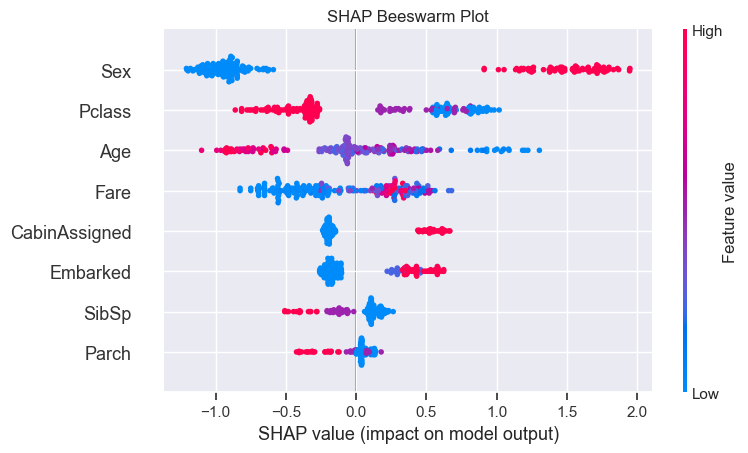

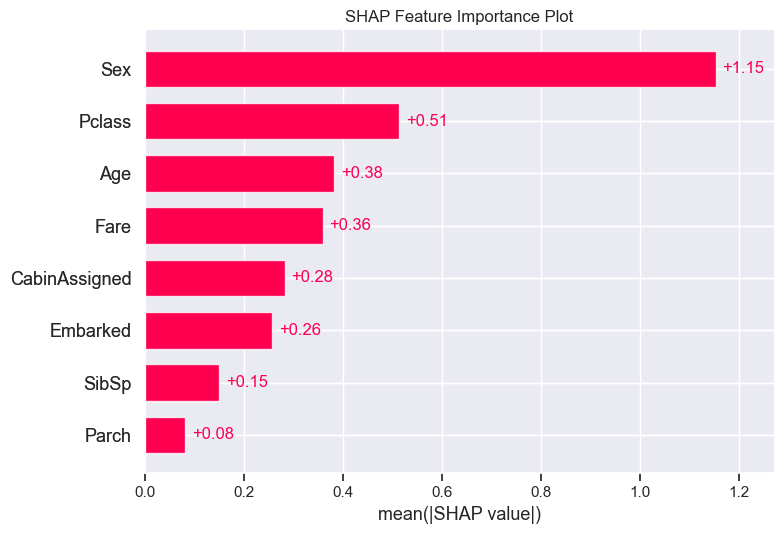

In [7]:
#================================================================================
# Step 5: XGBoost Baseline Model
model_xgb = XGBClassifier(seed=1023, objective ='binary:logistic', eval_metric='auc', n_estimators=10000, eta=0.001, max_depth=3, min_child_weight=5, subsample=0.5, colsample_bytree=0.5, grow_policy='lossguide')
model_xgb.fit(X_train, y_train)

pred_xgb_train=model_xgb.predict_proba(X_train)[:,1]
pred_xgb_test =model_xgb.predict_proba(X_test)[:,1]

print(f'Train Gini: ', roc_auc_score(y_true=y_train, y_score=pred_xgb_train)*2-1)
print(f'Test Gini : ', roc_auc_score(y_true=y_test, y_score=pred_xgb_test  )*2-1)

# SHAP Values
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test)

# Beeswarm
shap.plots.beeswarm(shap_values, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig("recursive-feature-elimination-beeswarm.png", dpi=300)
plt.show()

# Feature importance
shap.plots.bar(shap_values, show=False)
plt.title('SHAP Feature Importance Plot')
plt.tight_layout()
plt.savefig("recursive-feature-elimination-feature-importance.png", dpi=300)
plt.show()

# Feature importance Data Frame
FeatImp=pd.DataFrame({'Features': X_test.columns, 
                      'SHAP Importance' : np.abs(shap_values.values).mean(axis=0)})\
                      .sort_values('SHAP Importance', ascending=False)
#================================================================================

In [8]:
#================================================================================
# Step 6: Recursive Feature Elimination

# Initial cols
initialcols=X_train.columns.to_list()
this_cols=initialcols
results=pd.DataFrame()

for i in range(0, len(initialcols)):

    print(this_cols)
    this_X_train=X_train[this_cols].reset_index(drop=True)
    this_X_test=X_test[this_cols].reset_index(drop=True)

    model_xgb = XGBClassifier(seed=1023, objective ='binary:logistic', eval_metric='auc', n_estimators=10000, eta=0.001, max_depth=3, min_child_weight=5, subsample=0.5, colsample_bytree=0.5, grow_policy='lossguide')
    model_xgb.fit(this_X_train, y_train)

    pred_xgb_train=model_xgb.predict_proba(this_X_train)[:,1]
    pred_xgb_test =model_xgb.predict_proba(this_X_test)[:,1]

    gini_xgb_train=(roc_auc_score(y_true=y_train, y_score=pred_xgb_train)*2-1)
    gini_xgb_test =(roc_auc_score(y_true=y_test, y_score=pred_xgb_test  )*2-1)

    # SHAP Values
    explainer = shap.TreeExplainer(model_xgb)
    shap_values = explainer(this_X_train)

    # Feature importance Data Frame
    FeatImp=pd.DataFrame({'Features': this_X_train.columns, 
                          'SHAP Importance' : np.abs(shap_values.values).mean(axis=0)})\
                          .sort_values('SHAP Importance', ascending=False)

    Feature_to_Drop=FeatImp['Features'].to_list()[-1]
    temp=pd.DataFrame({'Iteration': i+1, 
                    'NumFeatures': len(this_X_train.columns),
                    'Train Gini' : gini_xgb_train,
                    'Test Gini' : gini_xgb_test,
                    'Feature to Drop': Feature_to_Drop,
                    'Features Used': [this_X_train.columns.to_list()]}, index=[0])

    results=pd.concat([results, temp])

    # Remove lowest SHAP value
    this_cols.remove(Feature_to_Drop)

#================================================================================

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'CabinAssigned']
['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked', 'CabinAssigned']
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'CabinAssigned']
['Pclass', 'Sex', 'Age', 'Embarked', 'CabinAssigned']
['Pclass', 'Sex', 'Age', 'CabinAssigned']
['Pclass', 'Sex', 'Age']
['Pclass', 'Sex']
['Sex']


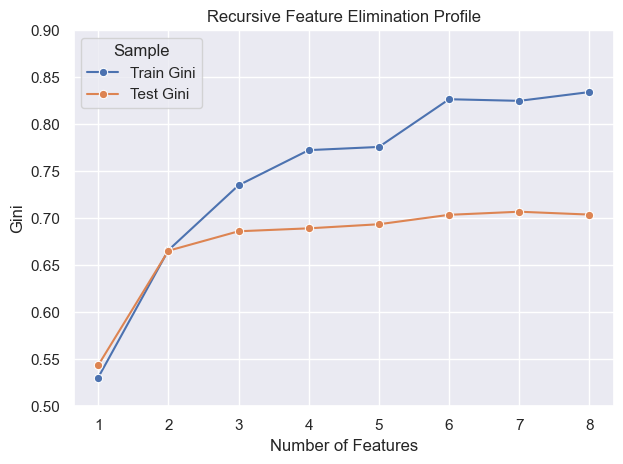

In [9]:
#================================================================================
# Step 7: Results

# Prepare for Plot
results2=pd.melt(results, 
                 id_vars='NumFeatures', 
                 value_vars=['Train Gini', 'Test Gini'], 
                 var_name='Sample', 
                 value_name='Gini')

# Plot RFE Profile
sns.lineplot(data=results2, 
             x='NumFeatures', 
             y='Gini',
             hue='Sample',
             marker='o')
plt.title('Recursive Feature Elimination Profile')
plt.xlabel('Number of Features')
plt.ylabel('Gini')
plt.ylim(0.5,0.9)
plt.tight_layout()
plt.savefig("recursive-feature-elimination-profile.png", dpi=300)
plt.show()
#================================================================================